# Notebook 01 — Data Exploration

## Overview
This notebook explores the **TMDB 5000 Movie Dataset** from Kaggle. Understanding the dataset is a critical first step before any machine learning or NLP task. We examine the structure, quality, and distribution of the data to inform our preprocessing and modelling decisions.

## Dataset
- **Source:** TMDB 5000 Movie Dataset (Kaggle)
- **Files used:** `tmdb_5000_movies.csv`, `tmdb_5000_credits.csv`
- **Size:** ~4,800 movies with metadata including genres, keywords, overview (plot), cast, and crew

## Goals
1. Load and inspect the raw data files
2. Understand the column structure and data types
3. Identify missing values
4. Visualise genre and rating distributions
5. Explore text fields (overview, keywords) that will be used for NLP

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os

# Set plot style
plt.style.use('dark_background')
sns.set_palette('husl')

RAW = '../data/raw'
FIGURES = '../reports/figures'
os.makedirs(FIGURES, exist_ok=True)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load the Dataset

We load both CSV files. `tmdb_5000_movies.csv` contains movie metadata such as title, genres, overview, and vote average. `tmdb_5000_credits.csv` contains cast and crew information.

In [3]:
movies = pd.read_csv(os.path.join(RAW, 'tmdb_5000_movies.csv'))
credits = pd.read_csv(os.path.join(RAW, 'tmdb_5000_credits.csv'))

print(f'Movies dataset:  {movies.shape[0]} rows, {movies.shape[1]} columns')
print(f'Credits dataset: {credits.shape[0]} rows, {credits.shape[1]} columns')
movies.head(3)

Movies dataset:  4803 rows, 20 columns
Credits dataset: 4803 rows, 4 columns


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


## 2. Column Overview

Key columns for this project:
- **`title`** — movie name (used for display)
- **`genres`** — list of genre dicts (JSON format)
- **`overview`** — plot description (main NLP input)
- **`keywords`** — thematic keywords (supplements genre)
- **`vote_average`** — TMDB rating out of 10
- **`cast`** (from credits) — list of actors

In [4]:
print('Movies columns:', list(movies.columns))
print()
print('Data types:')
print(movies.dtypes)

Movies columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Data types:
budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
dtype: object


## 3. Missing Value Analysis

Missing values in the `overview` field are critical — movies without plot descriptions cannot be represented meaningfully in our NLP pipeline.

In [5]:
missing = movies.isnull().sum()
missing_pct = (missing / len(movies) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

              Missing Count  Missing %
homepage               3091      64.36
overview                  3       0.06
release_date              1       0.02
runtime                   2       0.04
tagline                 844      17.57


## 4. Genre Distribution

Genres are stored as a JSON list of dictionaries. We parse them and count how often each genre appears across all movies. This tells us if the dataset is balanced across genres.

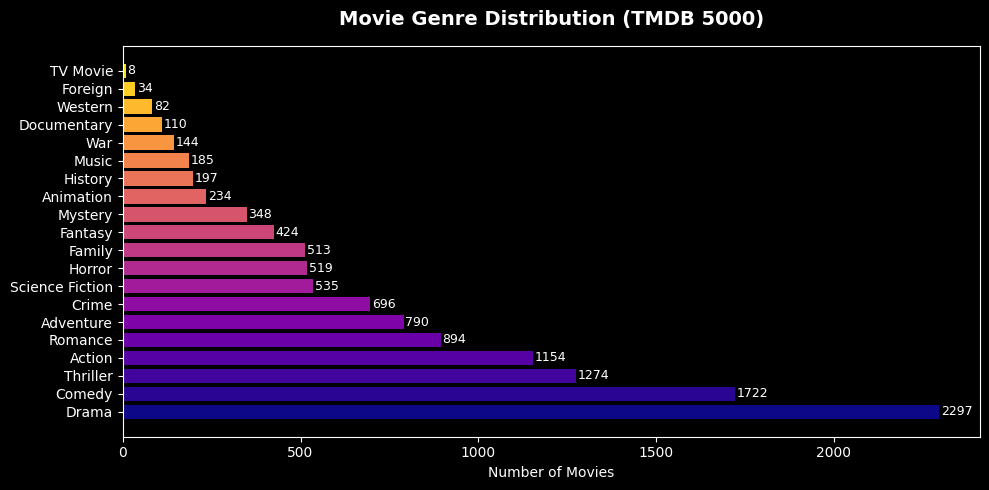

Total unique genres: 20


In [6]:
def extract_names(json_str):
    try:
        return [item['name'] for item in ast.literal_eval(str(json_str))]
    except:
        return []

all_genres = movies['genres'].apply(extract_names).explode()
genre_counts = all_genres.value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.plasma([i/len(genre_counts) for i in range(len(genre_counts))])
bars = ax.barh(genre_counts.index, genre_counts.values, color=colors)
ax.set_title('Movie Genre Distribution (TMDB 5000)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Movies')
for bar, val in zip(bars, genre_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES}/genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total unique genres: {len(genre_counts)}')

## 5. Rating Distribution

The `vote_average` gives us the TMDB community rating (0–10). Understanding this distribution helps justify why we use NLP-based content similarity rather than ratings alone — ratings do not capture what a movie *feels like* to watch.

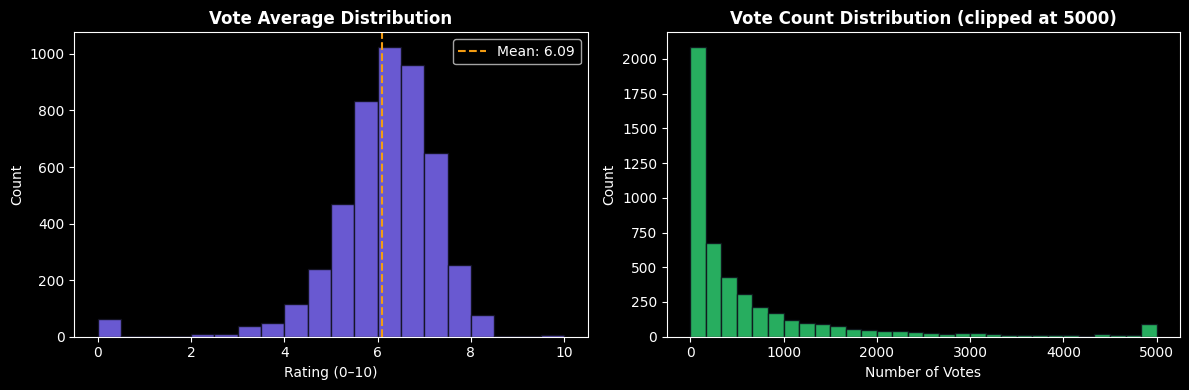

count    4803.000000
mean        6.092172
std         1.194612
min         0.000000
25%         5.600000
50%         6.200000
75%         6.800000
max        10.000000
Name: vote_average, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Vote average histogram
axes[0].hist(movies['vote_average'], bins=20, color='#7c6af7', edgecolor='#0f0f1a', alpha=0.85)
axes[0].set_title('Vote Average Distribution', fontweight='bold')
axes[0].set_xlabel('Rating (0–10)')
axes[0].set_ylabel('Count')
axes[0].axvline(movies['vote_average'].mean(), color='#f39c12', linestyle='--', label=f"Mean: {movies['vote_average'].mean():.2f}")
axes[0].legend()

# Vote count (popularity) histogram
axes[1].hist(movies['vote_count'].clip(upper=5000), bins=30, color='#2ecc71', edgecolor='#0f0f1a', alpha=0.85)
axes[1].set_title('Vote Count Distribution (clipped at 5000)', fontweight='bold')
axes[1].set_xlabel('Number of Votes')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{FIGURES}/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(movies['vote_average'].describe())

## 6. Overview (Plot) Text Length Analysis

The `overview` field is the primary text source for our NLP model. We analyse its length distribution to understand how much descriptive text is available per movie.

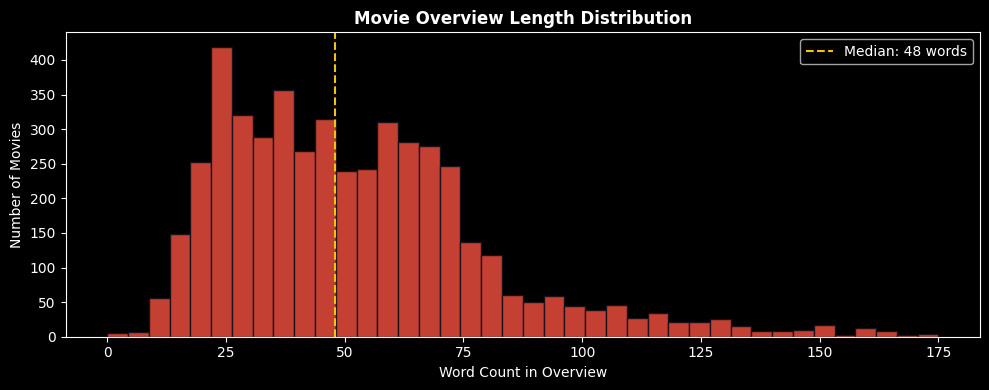

count    4803.000000
mean       52.124714
std        27.888777
min         0.000000
25%        30.000000
50%        48.000000
75%        67.000000
max       175.000000
Name: overview_len, dtype: float64


In [8]:
movies['overview_len'] = movies['overview'].fillna('').str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(movies['overview_len'], bins=40, color='#e74c3c', edgecolor='#0f0f1a', alpha=0.85)
ax.axvline(movies['overview_len'].median(), color='#f1c40f', linestyle='--',
           label=f"Median: {movies['overview_len'].median():.0f} words")
ax.set_title('Movie Overview Length Distribution', fontweight='bold')
ax.set_xlabel('Word Count in Overview')
ax.set_ylabel('Number of Movies')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES}/overview_length.png', dpi=150, bbox_inches='tight')
plt.show()
print(movies['overview_len'].describe())

## 7. Top Keywords

Keywords provide thematic tags assigned to movies. These supplement the plot overview and genres in our combined text representation.

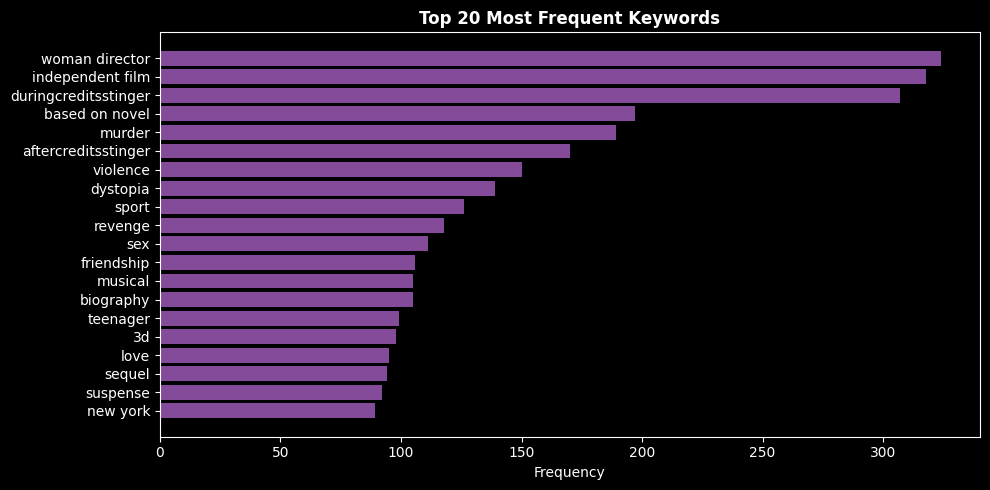

In [9]:
from collections import Counter

all_keywords = movies['keywords'].apply(extract_names).explode().dropna()
keyword_counts = Counter(all_keywords).most_common(20)

labels, values = zip(*keyword_counts)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(labels), list(values), color='#9b59b6', alpha=0.85)
ax.set_title('Top 20 Most Frequent Keywords', fontweight='bold')
ax.set_xlabel('Frequency')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{FIGURES}/top_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Insight | Finding |
|---------|----------|
| Dataset size | 4,803 movies |
| Most common genre | Drama, followed by Comedy and Thriller |
| Average rating | ~6.09 / 10 |
| Median overview length | ~40–50 words |
| Missing overviews | Very few (< 1%) |

**Conclusion:** The dataset is suitable for NLP-based content recommendation. The overview + keywords + genres fields give rich text representations for each movie.